In [1]:
import numpy as np

def hawk_dove_retaliator_payoff(V=1.0, C=2.0):
    """
    Hawk–Dove–Retaliator payoff matrix.
    Order: [Hawk, Retaliator, Dove]
    A[i, j] = payoff to strategy i against strategy j
    Assumes C > V.
    """
    return np.array([
        [(V - C) / 2, (V - C) / 2, V       ],  # Hawk vs (H, R, D)
        [(V - C) / 2, V / 2,       V / 2   ],  # Retaliator vs (H, R, D)
        [0,           V / 2,       V / 2   ]   # Dove vs (H, R, D)
    ], dtype=float)

A = hawk_dove_retaliator_payoff(V=1.0, C=2.0)

In [2]:
def replicator(populations, A, delta=0.05, N=2000):
    """Return the trajectory as a 2D numpy matrix and the final population as a 1D numpy array the same shape as the population."""
    populations = np.asarray(populations, float)
    populations = populations / populations.sum()

    # initialize the trajectory with the initial conditions
    trajectory = [populations.copy()]
    
    for _ in range(N):
        fitness = A @ populations # payoff for this iteration
        average = populations @ fitness
        
        populations = populations + delta * (populations * (fitness - average))

        # avoid extinction and normalize
        populations = np.clip(populations, 1e-6, 1 + delta) 
        populations = populations / populations.sum()
        
        trajectory.append(populations.copy())
    return np.array(trajectory), populations

# Example run from a random interior point
rng = np.random.default_rng()
initial_conditions = rng.dirichlet(np.ones(3))
print("Initial conditions:", initial_conditions)


trajectory, populations_final = replicator(initial_conditions, A, N=5_000)
print("Final populations (G, S, M):", populations_final.round(4))

Initial conditions: [0.42821633 0.07397411 0.49780957]
Final populations (G, S, M): [0.5 0.  0.5]


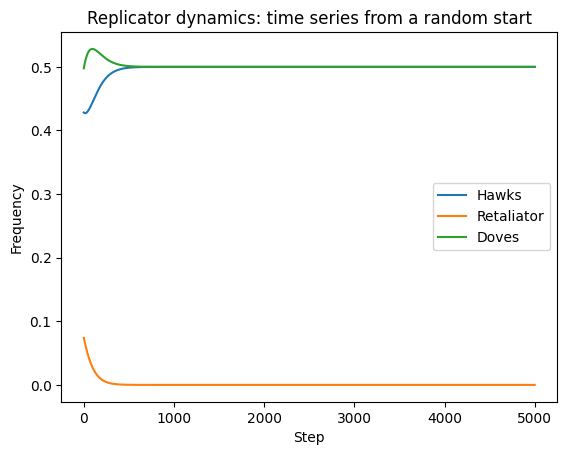

In [3]:
import matplotlib.pyplot as plt


def to_xy(p):
    # Map (x1, x2, x3) with sum=1 to equilateral triangle coordinates
    g, s, m = p[...,0], p[...,1], p[...,2]
    x = s + 0.5 * g
    y = (np.sqrt(3)/2) * g
    return np.stack([x, y], axis=-1)

def from_xy(xy):
    # Inverse map back to barycentric
    x, y = xy[...,0], xy[...,1]
    g = (2/np.sqrt(3)) * y
    s = x - 0.5 * g
    m = 1 - g - s
    P = np.stack([g, s, m], axis=-1)
    return P

def replicator_field(p, A):
    f = A @ p
    avg = p @ f
    dp = p * (f - avg)
    return dp


plt.figure()
plt.plot(trajectory[:,0], label="Hawks")
plt.plot(trajectory[:,1], label="Retaliator")
plt.plot(trajectory[:,2], label="Doves")
plt.xlabel("Step")
plt.ylabel("Frequency")
plt.title("Replicator dynamics: time series from a random start")
plt.legend()

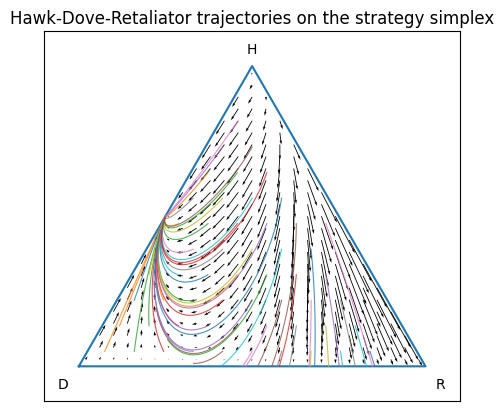

In [9]:
# --- 2) Multiple trajectories on the simplex ---
def plot_simplex_background():
    # Triangle
    tri = np.array([[0,0], [1,0], [0.5, np.sqrt(3)/2], [0,0]])
    plt.figure()
    plt.plot(tri[:,0], tri[:,1])
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, np.sqrt(3)/2 + 0.1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xticks([]); plt.yticks([])
    plt.title("Hawk-Dove-Retaliator trajectories on the strategy simplex")
    # Corner labels
    eps = 0.03
    plt.text(-eps, -eps, "D", ha="right", va="top")
    plt.text(1+eps, -eps, "R", ha="left", va="top")
    plt.text(0.5, np.sqrt(3)/2+eps, "H", ha="center", va="bottom")

plot_simplex_background()
# seed a small grid of initial points inside the simplex
seeds = []
for a in np.linspace(0.05, 0.9, 11):
    for b2 in np.linspace(0.05, 0.9, 11):
        if a + b2 < 0.95:
            g0 = a
            s0 = b2
            m0 = 1 - g0 - s0
            seeds.append([g0, s0, m0])

for p0 in seeds:
    tr = replicator(p0, A, delta=0.02)[0]
    XY = to_xy(tr)
    plt.plot(XY[:,0], XY[:,1], linewidth=0.8, alpha=0.8)

mask = (
    (P[..., 0] >= 0) &
    (P[..., 1] >= 0) &
    (P[..., 2] >= 0) &
    ((X % 2 != 0) | (Y % 2 != 0))
)
plt.quiver(X[mask], Y[mask], U[mask], V[mask], angles='xy', scale_units='xy', scale=0.02, width=0.002)
plt.gca().set_aspect('equal', adjustable='box')



Text(0.5, 1.0, 'Replicator vector field on the simplex')

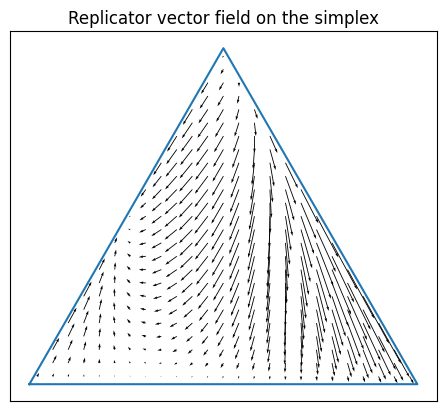

In [5]:
# --- 3) Vector field (quiver) over the simplex ---
# build a coarse grid over the triangle in (x,y), map to barycentric, compute dp/dt, project to xy
xs = np.linspace(0.02, 0.98, 25)
ys = np.linspace(0.02, np.sqrt(3)/2 - 0.02, 25)
X, Y = np.meshgrid(xs, ys)
XY = np.stack([X, Y], axis=-1)
P = from_xy(XY)

# mask points outside simplex
mask = (P[...,0] >= 0) & (P[...,1] >= 0) & (P[...,2] >= 0)
U = np.zeros_like(X); V = np.zeros_like(Y)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        if mask[i,j]:
            p = P[i,j]
            dp = replicator_field(p, A)
            # small step then map movement to XY
            p_next = p + 0.02 * dp
            p_next = np.clip(p_next, 1e-12, 1.0)
            p_next /= p_next.sum()
            dxy = to_xy(p_next) - to_xy(p)
            U[i,j], V[i,j] = dxy

plt.figure()
# draw triangle boundary
tri = np.array([[0,0], [1,0], [0.5, np.sqrt(3)/2], [0,0]])
plt.plot(tri[:,0], tri[:,1])
plt.quiver(X[mask], Y[mask], U[mask], V[mask], angles='xy', scale_units='xy', scale=0.02, width=0.002)
plt.gca().set_aspect('equal', adjustable='box')
plt.xticks([]); plt.yticks([])
plt.title("Replicator vector field on the simplex")